In [1]:
import sys
sys.path.append('..')
sys.path.append('../..')
from data_utils import *

import torch
import numpy as np
import pickle
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Subset
from transformer import *
import importlib
import wandb
import torch.optim as optim
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import matplotlib.gridspec as gridspec

import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if using CUDA

### Plotting Things and Sorting them

In [2]:
cd ..

/sdf/home/c/carsmith/flash_reconstruction/flash_detection


In [3]:
# Loading in data
load_wfs = np.load('/sdf/home/c/carsmith/sdf_data/flash_detection_data/flash_files/delay_200ks/2_8.npy', allow_pickle=True) # array of shape (2519, 5, 250, 250)
dataset = WaveformDataset(load_wfs.item())

g = torch.Generator()
g.manual_seed(seed)

# Splitting data
val_ratio = 0.1
test_ratio = 0.0
total_size = len(dataset)
val_size = int(total_size * val_ratio)
test_size = int(total_size * test_ratio)
train_size = total_size - val_size - test_size
print(f"split sizes: {train_size, val_size, test_size}")
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=g)

batch_size = 25

def custom_collate_fn(batch):
    """
    Custom collate function for WaveformDataset.
    Each item in batch is a tuple: (waveform, arrival_time).
    Returns:
        waveforms: Tensor of shape (batch_size, waveform_length)
        arrival_times: Tensor of shape (batch_size,) or (batch_size, 1)
        hit_times: Tensor of shape (?) with a list of hit times per sample
    """
    waveforms, arrival_times, hit_times, photon_bins, photon_list = zip(*batch)
    waveforms = torch.stack(waveforms, dim=0)

     # Normalizing waveforms
    waveforms = (waveforms - waveforms.mean(dim=1, keepdim=True)) / (waveforms.std(dim=1, keepdim=True) + 1e-8)
    waveforms = waveforms.unsqueeze(1)  # add channel dimension [B,1,L]

    # for binary classification
    arrival_times = torch.stack(arrival_times, dim=0)
    arrival_times = arrival_times.unsqueeze(1) # adding channel dimension
    photon_bins = torch.stack(photon_bins, dim=0)
    photon_bins = photon_bins.unsqueeze(1)

    # for regression, just use hit times
    hit_times = [item[2] for item in batch]
    hit_times = torch.tensor(hit_times)
    photon_list = [item[4] for item in batch]
    photon_list = torch.tensor(photon_list)
    
    return waveforms, arrival_times, hit_times, photon_bins, photon_list
    

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=g,
    collate_fn=custom_collate_fn,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=custom_collate_fn,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=custom_collate_fn,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

ModuleNotFoundError: No module named 'numpy._core'

In [ ]:
# Inspecting data
waveforms, arrival_times, hit_times, photon_bins, photon_list = next(iter(train_loader))
print(f"hit_times: {hit_times.shape}")
print(waveforms.shape)
print(arrival_times.shape)
ticks = np.arange(waveforms[0].shape[1])

waveform_id = 4
wf = waveforms[waveform_id]

ticks = torch.arange(wf.shape[-1])  # assume ticks = [0, 1, ..., length-1]
wf = wf.squeeze(0)  # shape: [length]

plt.figure(figsize = (10, 4))
plt.plot(ticks, wf, alpha=1, label='Waveform')

# FOR MULTIPLE HITS!
for j, t in enumerate(hit_times[waveform_id]):
    if t < 0:
        pass
    else:
        plt.axvline(
            x=t.item(), 
            color='r', 
            linestyle='--', 
            linewidth=1, 
            label='True arrival' if j == 0 else ""
        )
        
plt.title(f"Full Waveform {waveform_id}")
plt.xlabel(f"Time Tick, 1 tick = 0.001 us")
plt.ylabel("ADC")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pwd

In [4]:
## Testing waveform downsampling from `waveforms`
import sys
sys.path.append('..')
sys.path.append('../..')
from data_utils import *
from waveforms.waveforms_module.make_waveform import BatchedLightSimulation

device = torch.device('cuda:0')
sim = BatchedLightSimulation(cfg="../../waveforms/templates/waveform_sim.yaml").to(device)

params = dict()
params['light_tick_size'] = 0.001 # 100 picoseconds in microseconds units
params['downsample_factor'] = 10
params['tpb_tau'] = 0.002
sim.reconfigure(params)
print(sim.light_tick_size)
print(sim.downsample_factor)

wf = waveforms[waveform_id]
print(wf.shape)
print(sim.downsample_factor)



ModuleNotFoundError: No module named 'waveforms_module'

In [5]:
from conformer import *
from transformer import *
from utils import *
import torch.optim as optim
import wandb

epochs = 2
device = 'cuda'

# try tracking with wandb
# logger = wandb.init(
#     project="conformer",
#     name="5M_test",
#     config={
#         "epochs": epochs,
#         "batch_size": batch_size,
#         "lr": 1e-4,
#     }
# )

model = ConformerModel(d_model=256, num_heads=8, num_layers=4)
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")
# wandb.watch(model, log="all", log_freq=100)

criterion = torch.nn.BCEWithLogitsLoss() # combines sigmoid + loss
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

mode = 'mined_bce'

# results = train_model_2(model, train_loader, val_loader, scheduler, optimizer, device, epochs, mode, logger)
# wandb.finish()

ModuleNotFoundError: No module named 'torchaudio'

### Characterizing the Dataset

In [6]:
epoch = 0
epochs = 1
train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False, position=0, disable=True)
device = 'cuda'
# hash tables of a sort
photon_bins = torch.zeros((990,))
interval_bins = torch.zeros((8000,))

for i, (data, target, hit_times, photon_target, photon_list) in enumerate(train_progress):
    data, target, photon_target = data.to(device), target.to(device), photon_target.to(device) # both [B, 1, 8000]
    
    # get # photons per flash
    nonzero_mask = photon_list != 0
    nonzero_photons = photon_list[nonzero_mask]
    photon_bins[nonzero_photons - 11] += 1 # 0-indexed

    # get interval lengths
    for b in range(hit_times.shape[0]): # hit times has absolute time stamps of events
        mask = hit_times[b] != -1
        sample_times = torch.sort(hit_times[b][mask]).values # keep batch indices indices
        diffs = torch.diff(sample_times)
        diffs = diffs.long()
        bincounts = torch.bincount(diffs, minlength=interval_bins.shape[0])
        interval_bins += bincounts
    
# print(interval_bins[:200])
plt.figure(figsize=(10, 4))
plt.plot(interval_bins.cpu().numpy()[:600])  # First 200 bins
plt.xlabel("Interval Length")
plt.ylabel("Count")
plt.title("Interval Distribution")
plt.grid(True)
plt.show()

NameError: name 'train_loader' is not defined

In [ ]:
photon_bins = torch.zeros((990,))
interval_bins = torch.zeros((8000,))

diffs_list = []

for i, (data, target, hit_times, photon_target, photon_list) in enumerate(train_progress):
    data, target, photon_target = data.to(device), target.to(device), photon_target.to(device)  # [B, 1, 8000]
    
    # ---- Photon counts ----
    nonzero_mask = photon_list != 0
    nonzero_photons = photon_list[nonzero_mask]
    photon_bins[nonzero_photons - 11] += 1  # shift into [0..979] range

    # ---- Interval lengths ----
    for b in range(hit_times.shape[0]):
        mask = hit_times[b] != -1
        sample_times = torch.sort(hit_times[b][mask]).values  # valid photon times
        if sample_times.numel() > 1:  # need at least 2 to get a diff
            diffs = torch.diff(sample_times)
            diffs = diffs.long()
            diffs_list.append(diffs)

all_diffs = torch.cat(diffs_list)

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Get unique values and counts
values, counts = torch.unique(all_diffs, return_counts=True)

# Convert to numpy
arr = all_diffs.cpu().numpy()

# Compute statistics
mean_val = arr.mean()
median_val = np.median(arr)

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(arr, bins=range(0, arr.max() + 200, 200), edgecolor='black', label='_nolegend_')

plt.xlabel("Separation (binned by 200 ns)", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.title("Distribution of $\Delta T$", fontsize=14)

# Add grid with more ticks on y axis
plt.grid(which='both', linestyle='--')
# plt.gca().yaxis.set_major_locator(plt.MultipleLocator(500))   # adjust spacing as needed
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(10000))   # denser gridlines

# Add legend with mean & median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color='gold', linestyle='--', linewidth=2, label=f"Median = {median_val:.2f}")
plt.legend()

plt.show()


NameError: name 'all_diffs' is not defined

In [8]:
# Get unique values and counts
values, counts = torch.unique(all_diffs, return_counts=True)

# Convert to numpy
arr = all_diffs.cpu().numpy()

# Compute statistics
mean_val = arr.mean()
median_val = np.median(arr)

# Define quantile bins (e.g., quintiles → 20% increments)
quantiles = np.percentile(arr, [0, 20, 40, 60, 80, 100])

plt.figure(figsize=(6, 5))

# Background shading for density ranges
colors = ['#fad3cd', '#face5f', '#b7f7cb', '#d4f1fa', '#eadcfa']  # light → dark
for i in range(len(quantiles) - 1):
    plt.axvspan(quantiles[i], quantiles[i+1], color=colors[i], alpha=0.6,
                label=f"{i*20}–{(i+1)*20}%")

# Histogram
plt.hist(arr, bins=range(0, arr.max() + 200, 200), edgecolor='black', label='_nolegend_')

# Axis labels & title
plt.xlabel("Separation (binned by 200 ns)", fontsize=13)
plt.ylabel("$\Delta T$ Frequency", fontsize=13)
plt.title("Distribution of $\Delta T$", fontsize=14)

# Add grid with denser ticks
plt.grid(which='both', linestyle='--', alpha=0.6)
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(10000))  # example density

# Vertical lines for mean & median
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color='gold', linestyle='--', linewidth=2, label=f"Median = {median_val:.2f}")

plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'all_diffs' is not defined

In [9]:
print(all_diffs.float().mean().item())

NameError: name 'all_diffs' is not defined

In [10]:
photon_bin_edges = np.linspace(0, 990, 11)
interval_bin_edges = np.linspace(0, 8000, 201, dtype=int)  # 200 bins

# Compute bin widths and centers
photon_widths = np.diff(photon_bin_edges)
photon_centers = photon_bin_edges[:-1] + photon_widths / 2

interval_widths = np.diff(interval_bin_edges)
interval_centers = interval_bin_edges[:-1] + interval_widths / 2

rebinned_photon = torch.tensor([photon_bins[i:i+int(photon_widths[0])].sum() for i in range(0, len(photon_bins), int(photon_widths[0]))])
rebinned_interval = torch.tensor([interval_bins[i:i+int(interval_widths[0])].sum() for i in range(0, len(interval_bins), int(interval_widths[0]))])
# Convert your torch tensors to numpy
photon_bins_np = photon_bins.cpu().numpy()
interval_bins_np = interval_bins.cpu().numpy()

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(photon_centers, rebinned_photon, width=photon_widths, align='center', edgecolor='k')
plt.title("Photon Bin Histogram", fontsize=14)
plt.xticks(photon_bin_edges, labels=[int(t+10) for t in photon_bin_edges])
plt.xlabel("Photon Count", fontsize=13)
plt.ylabel("Flash Frequency", fontsize=13)

plt.subplot(1, 2, 2)
plt.bar(interval_centers, rebinned_interval, width=interval_widths, align='center', edgecolor='k')
plt.title(f"Interval Bin Histogram ({int(interval_widths[0])} ns bins)", fontsize=14)
plt.xlabel("Interval Length", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

plt.tight_layout()
plt.show()

NameError: name 'photon_bins' is not defined

In [11]:
from conformer import *
device = 'cuda'
model = ConformerModel(tokens=None)
model.to(device)

ModuleNotFoundError: No module named 'torchaudio'

In [12]:
# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

NameError: name 'model' is not defined

In [13]:
from model import *
model = UNet1D()
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

NameError: name 'device' is not defined

In [14]:
from transformer import *
model = TransformerModel()
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

NameError: name 'device' is not defined

In [15]:
from conformer import *
model = ConformerModel(d_model=256, num_heads=8, num_layers=4)
model.to(device)

ModuleNotFoundError: No module named 'torchaudio'

In [16]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Total number of parameters: 2418178


In [25]:
cd notebooks

/sdf/home/c/carsmith/flash_reconstruction/flash_detection/notebooks


In [28]:
ls

all_preds_59.npy                 old_data_gen2.ipynb
all_preds.npy                    old_loss_dev.ipynb
animation.ipynb                  old_single_amp_study.ipynb
animations/                      old_transformer_dev.ipynb
best_pois_sampled.npy            performance_analysis/
best_pois_smallt.npy             regression_dev.ipynb
CLEAN_regression_analysis.ipynb  reg_study.ipynb
compare_networks.ipynb           scratch-Copy1.ipynb
debug_reg.ipynb                  scratch.ipynb
decoding_model_scratch.ipynb     simulating_data.ipynb
final_analysis.ipynb             test_arr_2k.npy
loss_list.npy                    test_arr.npy
loss_list_smalldecay.npy         train_transformer.ipynb
merge_study.ipynb                train_unet.ipynb
no_delay_fixed_phot_samples/     wandb/
old_bin_precision.ipynb          wandb_stealing.ipynb


### Performance Analysis Scratch

In [26]:
### Accumulating All Results
unet_results = np.load("performance_analysis/singleflash_eval_stats.npy", allow_pickle=True).item() #UNet, tr_215
c5M_t2M_results = np.load("performance_analysis/c5M_t2M_singlephot_stats.npy", allow_pickle=True).item() #conformer5M, transformer2M
c_195K_results = np.load("performance_analysis/conform_trans5x_singlephot_stats.npy", allow_pickle=True).item() #conformer195K
conv3_results = np.load("performance_analysis/conv3_delta_random_results.npy", allow_pickle=True).item()

all_results = {**unet_results, **c5M_t2M_results, **c_195K_results, **conv3_results}
model_names = list(all_results.keys())   # ['tr', 'unet']
model_names.remove('tr_160')
model_names.remove('conformer_30')
model_names.remove('transformer_5x_40')
print(model_names)

FileNotFoundError: [Errno 2] No such file or directory: 'performance_analysis/singleflash_eval_stats.npy'

In [31]:
import numpy as np
delta_results = np.load("performance_analysis/delta_t_benchmark/deltastats_3trans_100k.npy", allow_pickle=True).item()
conformer_delta_results = np.load("performance_analysis/delta_t_benchmark/deltastats_conformers_trans5M_100k.npy", allow_pickle=True).item()
c5M_t2M_delta_results = np.load("performance_analysis/delta_t_benchmark/c5M_t2M_deltastats.npy", allow_pickle=True).item()
tr215_delta_results = np.load("performance_analysis/delta_t_benchmark/t215_deltastats.npy", allow_pickle=True).item()
less_overfit_conformer_results = np.load("performance_analysis/delta_t_benchmark/less_overfit_con_500deltas.npy", allow_pickle=True).item()
conv3_results = np.load("performance_analysis/delta_t_benchmark/conv3_e34_delta_random_results.npy", allow_pickle=True).item()
conv5_results = np.load("performance_analysis/delta_t_benchmark/conv5_pos_nomerge_delta_stats.npy", allow_pickle=True).item()


all_delta_results = {**delta_results, **tr215_delta_results, **conformer_delta_results, **c5M_t2M_delta_results, **less_overfit_conformer_results, **conv3_results, **conv5_results}

model_names = list(all_delta_results.keys())   # ['tr', 'unet']
print(model_names)
model_names.remove('tr_160')
model_names = list(all_delta_results.keys())   # ['tr', 'unet']

model_names.remove('tr_160')
model_names.remove('tr_180')
model_names.remove('conformer_30')
model_names.remove('transformer_5x_40')
model_names.remove('conformer_5M')
print(model_names)
print(all_delta_results['unet'].keys())

ModuleNotFoundError: No module named 'numpy._core'

In [20]:
delta_results = np.load("delta_t_50phot.npy", allow_pickle=True).item()
all_delta_results = delta_results

FileNotFoundError: [Errno 2] No such file or directory: 'delta_t_50phot.npy'

In [21]:
def aggregate_bins(delta_results, bin_size=1):
    """
    Aggregate results into coarser bins.
    bin_size = number of indices to merge (e.g. 10 for 10 ns bins).
    Uses mean over bins.
    """
    agg_results = {}

    for model, metrics in delta_results.items():
        agg_results[model] = {}
        n_bins = len(next(iter(metrics.values())))

        # Number of new bins after aggregation
        n_new = n_bins // bin_size
        new_bins = np.arange(n_new) * bin_size

        for key, arr in metrics.items():
            arr = np.array(arr)
            # truncate so it's divisible by bin_size
            arr = arr[:n_new * bin_size]
            arr = arr.reshape(n_new, bin_size).mean(axis=1)
            agg_results[model][key] = arr

        # Store new bin centers
        agg_results[model]["bin_centers"] = new_bins + bin_size / 2

    return agg_results

In [22]:
# Aggregate bins (change bin_size=10 for 10 ns bins, etc.)
bin_size = 30
all_delta_results = aggregate_bins(all_delta_results, bin_size=bin_size)
models = all_delta_results.keys()

paired_metrics = {
    "reco_frac": ("reco_frac_flash1", "reco_frac_flash2"),
    "merge_acc": ("merge_acc_flash1", "merge_acc_flash2"),
}
single_metrics = ["merge_pure"]

ncols = len(paired_metrics) + len(single_metrics)
nrows = len(models)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)

if nrows == 1:
    axes = np.expand_dims(axes, 0)

colors = ["steelblue", "darkorange"]

for row, model in enumerate(models):
    print(model)
    results = all_delta_results[model]
    print(results.keys())
    bin_centers = results['bin_centers'] + 50

    # ---- Paired metrics ----
    for col, (metric_name, (flash1_key, flash2_key)) in enumerate(paired_metrics.items()):
        ax = axes[row, col]
        ax.plot(bin_centers, results[flash1_key], label=f"Flash 1", color=colors[0], marker="o")
        ax.plot(bin_centers, results[flash2_key], label=f"Flash 2", color=colors[1], marker="s")

        ax.set_title(f"{model} - {metric_name}")
        ax.set_ylabel(metric_name)
        ax.grid(True, alpha=0.4)

        if row == nrows - 1:
            ax.set_xlabel(f"Separation (ns, aggregated by {bin_size})")
        if row == 0:
            ax.legend()

    # ---- Single metrics ----
    for j, metric_name in enumerate(single_metrics):
        col = len(paired_metrics) + j
        ax = axes[row, col]
        ax.plot(bin_centers, results[metric_name], label=metric_name, color="mediumseagreen", marker="D")

        ax.set_title(f"{model} - {metric_name}")
        ax.set_ylabel(metric_name)
        ax.grid(True, alpha=0.4)

        if row == nrows - 1:
            ax.set_xlabel(f"Separation (ns, aggregated by {bin_size})")
        if row == 0:
            ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'all_delta_results' is not defined

['unet', 'transformer_2M', 'conformer_5M', 'conformer_v2']


NameError: name 'bin_centers' is not defined

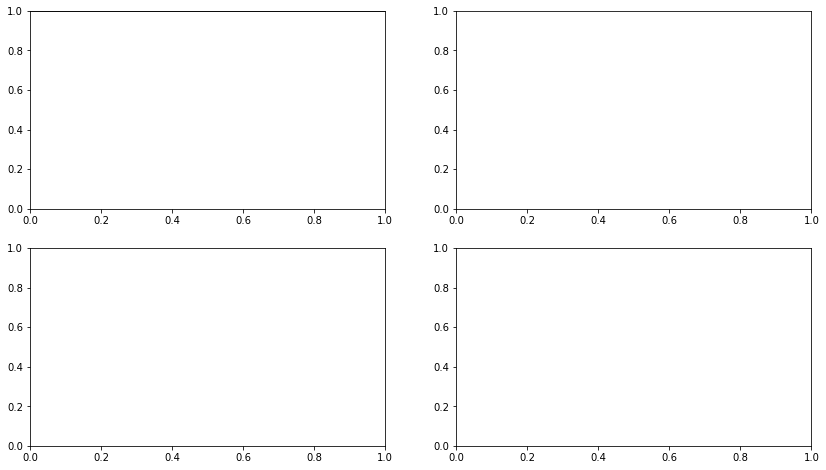

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
model_names = ['unet', 'transformer_2M', 'conformer_5M', 'conformer_v2']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))  # 2 rows, 2 cols
axes = axes.ravel()  # flatten into 1D array for easy indexing
# colors = ["steelblue", "mediumseagreen", "orange", "red", "purple", "pink", "darkslategrey", "darkblue", "gray"]
colors = ["steelblue", "mediumseagreen", "orange", "red", "red", "pink", "darkslategrey", "darkblue", "gray"]
markers = ["o", "s", "D", "v", "^", "o", "s", "o", "D"]
print(model_names)
# --- Top left: Accuracy Flash 1 ---
ax = axes[0]
ax.axhline(y=1, color='black', linestyle='-', linewidth=1.5)
for i, model in enumerate(model_names):
    color = colors[i]
    ax.plot(bin_centers-50, all_delta_results[model]['merge_acc_flash1'],
            marker=markers[i], markersize=6, color=color, label=model, linewidth=2)
ax.legend()
xmin, xmax = ax.get_xlim()
for x in range(15, int(xmax) + 30, 30):
    ax.axvline(x, color="gray", linestyle=":", linewidth=0.8)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="both", which="both", linestyle=":", linewidth=0.7)
ax.set_title("Merged Accuracy, Flash 1", fontsize=14)
ax.set_xlabel("Separation (ns, aggregated by 30)", fontsize=13)
ax.set_ylabel("Accuracy (%)", fontsize=13)

# --- Top right: Accuracy Flash 2 ---
ax = axes[1]
ax.axhline(y=1, color='black', linestyle='-', linewidth=1.5)
for i, model in enumerate(model_names):
    color = colors[i]
    ax.plot(bin_centers-50, all_delta_results[model]['merge_acc_flash2'],
            marker=markers[i], markersize=6, color=color, label=model, linewidth=2)
ax.legend()
xmin, xmax = ax.get_xlim()
for x in range(15, int(xmax) + 30, 30):
    ax.axvline(x, color="gray", linestyle=":", linewidth=0.8)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="both", which="both", linestyle=":", linewidth=0.7)
ax.set_title("Merged Accuracy, Flash 2", fontsize=14)
ax.set_xlabel("Separation (ns, aggregated by 30)", fontsize=13)
ax.set_ylabel("Accuracy (%)", fontsize=13)

# --- Bottom left: Reco Fraction Flash 1 ---
ax = axes[2]
ax.axhline(y=1, color='black', linestyle='-', linewidth=1.5)
for i, model in enumerate(model_names):
    color = colors[i]
    ax.plot(bin_centers-50, all_delta_results[model]['reco_frac_flash1'],
            marker=markers[i], markersize=6, color=color, label=model, linewidth=2)
ax.legend()
xmin, xmax = ax.get_xlim()
for x in range(15, int(xmax) + 30, 30):
    ax.axvline(x, color="gray", linestyle=":", linewidth=0.8)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="both", which="both", linestyle=":", linewidth=0.7)
ax.set_title("Reconstructed Photon Fraction, Flash 1", fontsize=14)
ax.set_xlabel("Separation (ns, aggregated by 30)", fontsize=13)
ax.set_ylabel("Reco Frac (pred/true)", fontsize=13)

# --- Bottom right: Reco Fraction Flash 2 ---
ax = axes[3]
ax.axhline(y=1, color='black', linestyle='-', linewidth=1.5)
for i, model in enumerate(model_names):
    color = colors[i]
    ax.plot(bin_centers-50, all_delta_results[model]['reco_frac_flash2'],
            marker=markers[i], markersize=6, color=color, label=model, linewidth=2)
ax.legend()
xmin, xmax = ax.get_xlim()
for x in range(15, int(xmax) + 30, 30):
    ax.axvline(x, color="gray", linestyle=":", linewidth=0.8)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="both", which="both", linestyle=":", linewidth=0.7)
ax.set_title("Reconstructed Photon Fraction, Flash 2", fontsize=14)
ax.set_xlabel("Separation (ns, aggregated by 30)", fontsize=13)
ax.set_ylabel("Reco Frac (pred/true)", fontsize=13)

# Layout
plt.tight_layout()
plt.show()

['unet', 'transformer_2M', 'conformer_5M', 'conformer_v2']


NameError: name 'bin_centers' is not defined

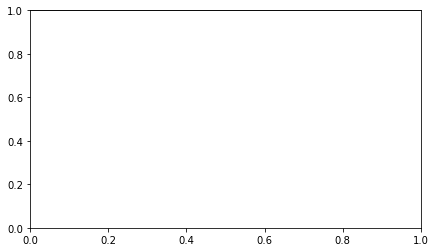

In [24]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4))  # 2 rows, 2 cols
colors = ["steelblue", "mediumseagreen", "orange", "red", "purple", "pink", "darkslategrey", "darkblue", "gray"]
markers = ["o", "s", "D", "v", "^", "o", "s", "o", "D"]
print(model_names)
ax = axes
# --- Top left: Accuracy Flash 1 ---
ax.axhline(y=1, color='black', linestyle='-', linewidth=1.5)
for i, model in enumerate(model_names):
    color = colors[i]
    ax.plot(bin_centers-50, all_delta_results[model]['merge_pure'],
            marker=markers[i], markersize=6, color=color, label=model, linewidth=2)
xmin, xmax = ax.get_xlim()
for x in range(15, int(xmax) + 30, 30):
    ax.axvline(x, color="gray", linestyle=":", linewidth=0.8)
ax.legend()
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="both", which="both", linestyle=":", linewidth=0.7)
ax.set_title("Merged Purity", fontsize=14)
ax.set_xlabel("Separation (ns, aggregated by 30)", fontsize=13)
ax.set_ylabel("Purity", fontsize=13)

In [ ]:
print(all_delta_results['conformer_v2']['merge_pure'])

In [ ]:
print(1500/30)
print(len(all_delta_results['conformer_v2']['merge_acc_flash1']))
print(bin_centers - 50)

## Single Flash Load & Plotting

In [ ]:
cd notebooks

In [ ]:
# --- Load the YAML config ---
import yaml
with open("../model_list.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Dictionary to hold results ---
single_flash_results = {}

# --- Iterate over models in YAML ---
for model_name, model_info in config.items():
    if not model_info.get("include", False):
        continue  # skip models not marked for use

    pstats_path = model_info.get("single_flash_pstats")
    if not pstats_path:
        print(f"⚠️ No single_flash_pstats for {model_name}, skipping.")
        continue

    try:
        stats = np.load(pstats_path, allow_pickle=True).item()
        single_flash_results[model_name] = stats
        print(f"✅ Loaded results for {model_name} from {pstats_path}")
    except Exception as e:
        print(f"❌ Could not load stats for {model_name}: {e}")

# --- Merge into one flat dict like {**dict1, **dict2, ...} ---
all_results = {}
for stats in single_flash_results.values():
    all_results.update(stats)

In [ ]:
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MultipleLocator

colors = ["mediumseagreen", "orange", "red", "purple"]
markers = ["o", "s", "D", "v", "^"]
model_names = list(all_results.keys())
# model_names.remove('conformer_30')
# model_names.remove('transformer_5x_40')
# model_names.remove('tr_160')
# model_names.remove('tr_215')
# model_names = ['unet', 'conformer_5M', 'transformer_2M', 'conformer_mlp']
#['conformer_5M', 'transformer_2M', 'conformer_30', 'conformer_50', 'transformer_5x_40', 'conformer_mlp', 'conformer_v2', 'conformer_v5_drop', 'conformer_v5', 'tr_160', 'tr_215', 'unet']

# Convert each model's data into arrays
model_reco_frac = {name: np.array(all_results[name]["reco_frac"]) for name in model_names}
model_interval = {name: np.array(all_results[name]["interval"]) for name in model_names}
model_acc = {name: np.array(all_results[name]["merge_acc"]) for name in model_names}
model_pure = {name: np.array(all_results[name]["merge_pure"]) for name in model_names}

# Define binning
bin_size = 100
ref_data = next(iter(model_reco_frac.values()))  # reference length
print(ref_data.shape)
bin_sizes = [20, 20, 20, 30] + [bin_size] * (len(ref_data) // bin_size)
bin_edges = np.cumsum([10] + bin_sizes)
bin_centers = bin_edges[:-1] + (np.array(bin_sizes) / 2)

def bin_data(arr, bin_sizes):
    """Average data into bins of variable width."""
    out, start = [], 0
    for b in bin_sizes:
        out.append(arr[start:start+b].mean())
        start += b
    return np.array(out)

# Create 1x2 plot
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
axes = axes.flatten()
# -------- Plot reco_frac --------
ax = axes[0]
for idx, name in enumerate(model_names):
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    binned = bin_data(model_reco_frac[name], bin_sizes)
    ax.plot(bin_centers, binned, label=name, color=color, marker=marker)

# Bin edges
for i, edge in enumerate(bin_edges):
    ax.axvline(edge, color="gray", linestyle=":", linewidth=0.8,
               label="Bin Edges" if i == 0 else None)
# ax.set_xlabel("# of Photons")
ax.axhline(1, color="black", linestyle="-", linewidth=2)
ax.set_ylabel("Reco Frac (pred / true)", fontsize=13)
ax.set_title("Reconstructed Photon Fraction", fontsize=14)
ax.set_xticks(bin_edges)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="y", which="both", linestyle=":", linewidth=0.7)
# ax.grid(axis="y")
ax.legend()

# -------- Plot interval --------
ax = axes[1]
for idx, name in enumerate(model_names):
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    binned = bin_data(model_interval[name], bin_sizes)
    ax.plot(bin_centers, binned, label=name, color=color, marker=marker)

for i, edge in enumerate(bin_edges):
    ax.axvline(edge, color="gray", linestyle=":", linewidth=0.8,
               label="Bin Edges" if i == 0 else None)

# ax.set_xlabel("# of Photons")
ax.set_ylabel("Interval", fontsize=13)
ax.set_title("Detected Region Width (ns)", fontsize=14)
ax.set_xticks(bin_edges)
# ax.set_xticklabels(bin_edges, rotation=45)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="y", which="both", linestyle=":", linewidth=0.7)
ax.legend()

# -------- Plot Accuracy --------
ax = axes[2]
for idx, name in enumerate(model_names):
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    binned = bin_data(model_acc[name], bin_sizes)
    ax.plot(bin_centers, binned, label=name, color=color, marker=marker)

for i, edge in enumerate(bin_edges):
    ax.axvline(edge, color="gray", linestyle=":", linewidth=0.8,
               label="Bin Edges" if i == 0 else None)
ax.axhline(1, color="black", linestyle="-", linewidth=2)
ax.set_xlabel("# of Photons", fontsize=13)
ax.set_ylabel("Merged Accuracy", fontsize=13)
ax.set_title("Accuracy", fontsize=14)
ax.set_xticks(bin_edges)
ax.set_xticklabels(bin_edges, rotation=45)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="y", which="both", linestyle=":", linewidth=0.7)
ax.legend()

# -------- Plot Purity --------
ax = axes[3]
for idx, name in enumerate(model_names):
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    binned = bin_data(model_pure[name], bin_sizes)
    ax.plot(bin_centers, binned, label=name, color=color, marker=marker)

for i, edge in enumerate(bin_edges):
    ax.axvline(edge, color="gray", linestyle=":", linewidth=0.8,
               label="Bin Edges" if i == 0 else None)
ax.axhline(1, color="black", linestyle="-", linewidth=2)
ax.set_xlabel("# of Photons", fontsize=13)
ax.set_ylabel("Merged Purity", fontsize=13)
ax.set_title("Purity", fontsize=14)
ax.set_xticks(bin_edges)
ax.set_xticklabels(bin_edges, rotation=45)
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.grid(axis="y", which="both", linestyle=":", linewidth=0.7)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
from evaluation import *
train_progress = tqdm(train_loader, desc=f"Epoch {3+1}/{3}", leave=False, position=0)
device = 'cuda'
for batch_idx, (data, target, hit_times, photon_target, photon_list) in enumerate(train_progress):
    data = data.to(device)
    target = target.to(device)
    photon_target = photon_target.to(device)
    break

class_output, reg_output = model(data, mode="bce")
merged_mask = merge_bins(class_output, skip_tol=5)
testing = max_photons_in_intervals(photon_target, merged_mask)
print(testing)

In [ ]:
class_output, reg_output = model(data, mode="bce")
                    merged_mask = merge_bins(class_output, skip_tol=5)
    
                    if config["double_flash"]["reco_frac"]:
                        interval_pred_sums = sum_photons_in_intervals_vecwgrad(predict_fn(reg_output), merged_mask, keep_grads=False)

In [ ]:
import sys
sys.path.append('..')
sys.path.append('../..')
from data_utils import *
from waveforms.waveforms_module.make_waveform import BatchedLightSimulation

import torch
import numpy as np
import pickle
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Subset
import importlib
import wandb
import torch.optim as optim
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import yaml

from transformer import *
from hybrid_loss import *
from model import *
from evaluation import *
from conformer import *

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if using CUDA

# Load Analysis Config
with open("../performance_analysis_config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Load Models
device='cuda'

MODEL_CLASSES = {
    "TransformerModel": TransformerModel,
    "ConformerModel": ConformerModel,
    "ConformerModelv2": ConformerModelv2,
    "UNet1D": UNet1D
}

models = load_models("../model_list.yaml", MODEL_CLASSES)
print(models.keys())

###################################### Single Flash ###########################################
if any(config["single_flash"].values()):
    
    merge_loader = make_dataloader("/sdf/home/c/carsmith/sdf_data/flash_detection_data/flash_files/1delayphot_reg.npy", seed=42, batch_size=25, shuffle=False)
    print("Single Flash Loader Length: ", len(merge_loader))
    bin_width = 100
    batches_per_photon = 4
    single_phot_results = {name: {"merge_acc": [], "merge_pure": [], "interval": [], "reco_frac": []} for name in models.keys()}
    epochs = 1
    
    for epoch in range(epochs):
        acc_progress = tqdm(merge_loader, desc=f"Scanning {epoch+1}/{epochs}", leave=False, position=0)
    
        # temporary accumulators
        interval_bins = {name: [] for name in models.keys()}
        reco_frac = {name: 0.0 for name in models.keys()}
        merged_acc = {name: 0.0 for name in models.keys()}
        merged_pure = {name: 0.0 for name in models.keys()}
        avg_interval = None
    
        with torch.no_grad():
            for i, (data, target, hit_times, photon_target, photon_list) in enumerate(acc_progress):
                data, target, photon_target = data.to(device), target.to(device), photon_target.to(device)
    
                # loop through all models in dict
                for name, (model, reg_loss) in models.items():
                    predict_fn = torch.expm1 if reg_loss == 'mse' else torch.exp
                    
                    class_output, reg_output = model(data, mode="bce")
                    merged_mask = merge_bins(class_output, skip_tol=5)
    
                    # interval widths
                    for b in range(merged_mask.shape[0]):
                        mask_row = merged_mask[b, 0]
                        intervals = mask_to_intervals(mask_row)
                        widths = [(e - s + 1) for (s, e) in intervals]
                        interval_bins[name].extend(widths)
        
                    if config["single_flash"]["reco_frac"]:
                        # interval_pred_sums = sum_photons_in_intervals_vecwgrad(predict_fn(reg_output), merged_mask, keep_grads=False)
                        # interval_true_sums = sum_photons_in_intervals_vecwgrad(photon_target, merged_mask, keep_grads=False)
                        # pred = torch.tensor([np.sum(x) for x in interval_pred_sums])
                        # true = torch.tensor([np.sum(x) for x in interval_true_sums])
                        # pred = torch.stack([torch.stack(x).sum() for x in interval_pred_sums])
                        # true = torch.stack([torch.stack(x).sum() for x in interval_true_sums])
                        
                        interval_pred_sums = max_photons_in_intervals(predict_fn(reg_output), merged_mask)
                        interval_true_sums = max_photons_in_intervals(photon_target, merged_mask)

                        pred = torch.cat([torch.tensor(x, dtype=torch.float32) for x in interval_pred_sums])
                        true = torch.cat([torch.tensor(x, dtype=torch.float32) for x in interval_true_sums])
                        
                        mask = true > 0
                        if mask.any():
                            reco_frac[name] += torch.mean(pred[mask] / true[mask]).item()
                        print(reco_frac[name])
                        print(interval_pred_sums)
                        print(interval_true_sums)

                break
            break
        break

In [ ]:
print(interval_true_sums)